<a href="https://colab.research.google.com/github/anubhavsin2020-web/CDCNpp/blob/main/CDCN_internship_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# This machine's RTX 5070 (compute capability 12.0a, Blackwell) needs a CUDA
# ptxas newer than 12.6.3 to JIT-compile all kernels -- without this,
# model.fit() fails outright on backward-conv kernels ("Autotuner could not
# compile any configs"). The system's own CUDA install was 12.4 (too old);
# it's since been upgraded to CUDA 13, but that toolkit's ptxas is ABI
# -incompatible with this environment's pip-installed CUDA 12.9 runtime libs
# (nvidia-cudnn-cu12, nvidia-cublas-cu12, etc.) and segfaults if used directly.
# The fix: point TensorFlow at the ptxas bundled with the matching pip package
# (nvidia-cuda-nvcc-cu12, already CUDA 12.9 -- new enough) instead of either
# the system's old or new toolkit. Must run before the first GPU op executes,
# so it's here, before `import tensorflow`.
try:
    import nvidia.cuda_nvcc
    _nvcc_bin = os.path.join(list(nvidia.cuda_nvcc.__path__)[0], 'bin')
    os.environ['PATH'] = _nvcc_bin + os.pathsep + os.environ.get('PATH', '')
except ImportError:
    pass

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow {tf.__version__}, Keras {keras.__version__}')

I0000 00:00:1783755532.918883    2457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783755533.311342    2457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783755535.708917    2457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0, Keras 3.15.0


In [2]:
BN_MOMENTUM = 0.9
BN_EPSILON = 1e-5
CONV_INIT = keras.initializers.HeNormal()
THETA = 0.7

In [3]:
class CDC(layers.Layer):
    def __init__(self, out_ch, kernel_size=3, strides=1, theta=THETA, **kwargs):
        super().__init__(**kwargs)
        self.theta = theta
        self.vani = layers.Conv2D(
            out_ch, kernel_size=kernel_size, strides=strides, padding='same',
            use_bias=False, kernel_initializer=CONV_INIT,
        )

    def call(self, x):
        out_vanilla = self.vani(x)
        if self.theta == 0.0:
            return out_vanilla
        kernel_diff = tf.reduce_sum(self.vani.kernel, axis=(0, 1), keepdims=True)
        out_cd = tf.nn.conv2d(x, kernel_diff, strides=1, padding='SAME')
        return out_vanilla - self.theta * out_cd

In [4]:
test_cdc = CDC(8, theta=0.0)
test_input = tf.random.normal((1, 16, 16, 8))
out_cdc = test_cdc(test_input)
out_vani = test_cdc.vani(test_input)
tf.debugging.assert_near(out_cdc, out_vani, atol=1e-6)
print(f'theta=0 identity holds. Shape: {tuple(out_cdc.shape)}')

# 2. theta=1 on a constant input: interior output should be ~0.
test_cdc_full = CDC(8, theta=1.0)
const_input = tf.ones((1, 16, 16, 8))
out_const = test_cdc_full(const_input)
interior = out_const[:, 1:-1, 1:-1, :]   # strip the 1-pixel padded border
max_interior = tf.reduce_max(tf.abs(interior)).numpy()
max_full = tf.reduce_max(tf.abs(out_const)).numpy()
print(f'theta=1, constant input — interior max|output| = {max_interior:.2e}  (expected ~0)')
print(f'                         full max|output|     = {max_full:.2e}  (boundary effects)')

W0000 00:00:1783755552.716275    2457 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1783755552.723276    2457 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1783755552.958262    2457 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1783755552.959438    2457 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5112 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1783755560.029058    2457 cuda_dnn.cc:461] Loaded cuDNN version 92400


theta=0 identity holds. Shape: (1, 16, 16, 8)
theta=1, constant input — interior max|output| = 9.61e-04  (expected ~0)
                         full max|output|     = 2.13e+00  (boundary effects)


In [5]:
class CDCBnRelu(layers.Layer):
    def __init__(self, out_ch, **kwargs):
        super().__init__(**kwargs)
        self.cdc = CDC(out_ch)
        self.bn = layers.BatchNormalization(momentum=BN_MOMENTUM, epsilon=BN_EPSILON)
        self.relu = layers.ReLU()

    def call(self, x, training=False):
        x = self.cdc(x)
        x = self.bn(x, training=training)
        x = self.relu(x)
        return x

In [6]:
class CDC2r(layers.Layer):
    def __init__(self, out_ch, r, **kwargs):
        super().__init__(**kwargs)
        mid = round(out_ch * r)
        self.block1 = CDCBnRelu(mid)
        self.block2 = CDCBnRelu(out_ch)

    def call(self, x, training=False):
        x = self.block1(x, training=training)
        x = self.block2(x, training=training)
        return x

In [7]:
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv2D(
            1, kernel_size=kernel_size, padding='same',
            use_bias=False, kernel_initializer=CONV_INIT,
        )

    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx = tf.reduce_max(x, axis=-1, keepdims=True)
        attn = tf.concat([avg, mx], axis=-1)
        attn = tf.sigmoid(self.conv(attn))
        return x * attn

In [8]:
def resize_to(x, target_hw):
  h = x.shape[1]
  if h == target_hw:
    return x

  pool = h // target_hw
  return tf.nn.avg_pool2d(x, pool, pool, 'VALID')

In [9]:
class MAFM(layers.Layer):
  def __init__(self, target_hw = 32, k_low=7, k_mid=5, k_high=3, **kwargs):
    super().__init__(**kwargs)
    self.target_hw = target_hw
    self.attn_low = SpatialAttention(k_low)
    self.attn_mid = SpatialAttention(k_mid)
    self.attn_high = SpatialAttention(k_high)

  def call(self, low, mid, high):

    low_r = resize_to(self.attn_low(low), self.target_hw)
    mid_r = resize_to(self.attn_mid(mid), self.target_hw)
    high_r = resize_to(self.attn_high(high), self.target_hw)

    return tf.concat([low_r, mid_r, high_r], axis=-1)


In [10]:
#Building CDC using the functions I built earlier

class CDCN(keras.Model):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)
    self.stem = CDCBnRelu(64)

    self.low = keras.Sequential([
        CDCBnRelu(128),
        CDCBnRelu(196),
        CDCBnRelu(128),
    ])
    self.mid  = keras.Sequential([
        CDCBnRelu(128),
        CDCBnRelu(196),
        CDCBnRelu(128),
    ])
    self.high = keras.Sequential([
        CDCBnRelu(128),
        CDCBnRelu(196),
        CDCBnRelu(128),
    ])
    self.pool = keras.layers.MaxPooling2D(pool_size=3, strides=2, padding='same')
    self.head_a = CDCBnRelu(128)
    self.head_b = CDCBnRelu(64)
    self.head_out = CDC(1)

  def call(self, x, training=False, **kwargs):

    x = self.stem(x, training=training)
    low = self.pool(self.low(x, training=training))
    mid = self.pool(self.mid(low, training=training))
    high = self.pool(self.high(mid, training=training))

    fused = tf.concat([resize_to(low, 32),
                       resize_to(mid, 32),
                       high,
                       ], axis=-1)
    x = self.head_a(fused, training=training)
    x = self.head_b(x, training=training)
    return self.head_out(x)



In [ ]:
class CDCNpp(keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.stem = keras.Sequential([
            CDCBnRelu(64),
            CDCBnRelu(128),
        ])

        self.low_cell = keras.Sequential([
            CDCBnRelu(128),
            CDCBnRelu(128),
        ])

        self.mid_cell = keras.Sequential([
            CDC2r(128, r=1.6),
            CDC2r(128, r=1.2),
            CDC2r(128, r=1.4),
        ])

        self.high_cell = keras.Sequential([
            CDCBnRelu(128),
            CDC2r(128, r=1.2),
        ])
        self.pool = layers.MaxPooling2D(pool_size=3, strides=2, padding = 'same')
        self.mafm = MAFM(target_hw=32, k_low=7, k_mid=5, k_high=3)
        self.head_a = CDCBnRelu(128)
        self.head_out = CDC(1)

        # Auxiliary live/spoof classification head. Gives the network a
        # direct classification gradient instead of relying entirely on
        # "mean of the depth map" as a proxy for the label -- the depth-only
        # setup was the leading cause of the model collapsing to a constant,
        # input-independent output.
        self.cls_pool = layers.GlobalAveragePooling2D()
        self.cls_dense = layers.Dense(1, activation='sigmoid')

    def call(self, x, training=False):

        x = self.stem(x, training=training)
        low = self.pool(self.low_cell(x, training=training))
        mid = self.pool(self.mid_cell(low, training=training))
        high = self.pool(self.high_cell(mid, training=training))

        fused = self.mafm(low, mid, high)

        feat = self.head_a(fused, training=training)
        depth_out = self.head_out(feat)
        cls_out = self.cls_dense(self.cls_pool(feat))
        return {'depth': depth_out, 'cls': cls_out}


In [12]:
def contrastive_loss(y_true, y_pred):

  dy_truth, dx_truth = tf.image.image_gradients(y_true)
  dy_pred, dx_pred = tf.image.image_gradients(y_pred)

  loss_x = tf.reduce_mean(tf.square(dx_truth - dx_pred))
  loss_y = tf.reduce_mean(tf.square(dy_truth - dy_pred))

  return loss_x + loss_y

def total_cdcn_loss(y_true, y_pred):
  y_true = tf.convert_to_tensor(y_true)
  y_pred = tf.convert_to_tensor(y_pred)
  mse_loss = tf.reduce_mean(tf.compat.v1.losses.mean_squared_error(y_true, y_pred))
  cdl_loss = contrastive_loss(y_true, y_pred)

  return mse_loss + cdl_loss


In [13]:
import datasets
from datasets import load_dataset
ds = load_dataset("nguyenkhoa/celeba-spoof-for-face-antispoofing-test")


/home/anubhav/cdcn_gpu_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 67170/67170 [00:07<00:00, 9339.27 examples/s] 


## Geometry-based depth targets

The depth-map target for live faces was previously a random Gaussian blob
re-drawn on *every* `__getitem__` call, i.e. a different ground-truth for the
same image on every epoch. Regressing against a target that moves randomly
each epoch has no stable input->output mapping to learn, so the network's
best available strategy was to output something close to the *average*
target and ignore the input entirely -- this is what caused the collapse to
"predict live for everything" seen in the last evaluation run.

The fix: a genuinely per-image, deterministic depth target derived from real
face geometry. `mediapipe`'s FaceLandmarker was the first choice (proper 3D
mesh with per-vertex depth), but it segfaults natively in this WSL
environment (GL/EGL context issue) and its legacy `solutions` API conflicts
with the protobuf version this environment's TensorFlow install needs.
Instead this uses OpenCV's bundled Haar cascade (face detection) + LBF
facemark model (68 2D landmarks, `cv2.face`, no extra native deps beyond
`opencv-contrib-python`, already required elsewhere in this repo), combined
with a fixed anatomical "protrusion toward camera" prior per landmark index
(nose tip highest, jaw line lowest, etc). The result varies with each
image's actual detected face geometry/pose -- unlike the old random blob --
and is cached per dataset index so it never changes across epochs.

In [ ]:
import os
import urllib.request
import cv2
import numpy as np

_ASSET_DIR = os.path.expanduser('~/cdcn_assets')
os.makedirs(_ASSET_DIR, exist_ok=True)

_HAAR_PATH = os.path.join(_ASSET_DIR, 'haarcascade_frontalface_default.xml')
_LBF_PATH = os.path.join(_ASSET_DIR, 'lbfmodel.yaml')

# cv2.data.haarcascades is broken in this environment (the opencv-contrib-python
# install here doesn't ship the bundled cascade data), so fetch straight from
# OpenCV's repo instead. Also affects the raw-photo test cell further down,
# which references cv2.data.haarcascades directly -- point it at _HAAR_PATH too
# if you hit the same "Can't open file" error there.
if not os.path.exists(_HAAR_PATH):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml',
        _HAAR_PATH,
    )
if not os.path.exists(_LBF_PATH):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/kurnianggoro/GSOC2017/master/data/lbfmodel.yaml',
        _LBF_PATH,
    )

_face_cascade = cv2.CascadeClassifier(_HAAR_PATH)
_facemark = cv2.face.createFacemarkLBF()
_facemark.loadModel(_LBF_PATH)

# Coarse anatomical "protrusion toward camera" prior for the standard 68-point
# iBUG landmark layout (jaw=0-16, brows=17-26, nose=27-35, eyes=36-47,
# mouth=48-67). Not biometrically precise -- just enough structure that the
# depth target varies with actual per-image face geometry/pose instead of
# being pure noise (old random blob) or a class-wide constant.
LANDMARK_DEPTH_TEMPLATE = np.array(
    [0.10] * 17 +               # jaw line -- recedes toward the silhouette
    [0.45] * 10 +               # eyebrows
    [0.60, 0.72, 0.85, 1.00] +  # nose bridge -> tip (most protruding point)
    [0.80] * 5 +                # nostrils / nose base
    [0.40] * 12 +               # eyes (recessed into the socket)
    [0.55] * 12 +               # outer mouth
    [0.50] * 8,                 # inner mouth
    dtype=np.float32,
)
assert LANDMARK_DEPTH_TEMPLATE.shape[0] == 68


def geometry_depth_map(img_rgb_uint8, depth_size=32):
    """Detects a face + 68 landmarks in img_rgb_uint8 and rasterizes
    LANDMARK_DEPTH_TEMPLATE onto a depth_size x depth_size grid using the
    landmarks' actual per-image (x, y) positions. Returns None if no face
    is detected (rare -- CelebA-Spoof's 'cropped_image' field is already
    tightly cropped to the face)."""
    gray = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
    faces = _face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        return None
    ok, landmark_sets = _facemark.fit(img_rgb_uint8, faces)
    if not ok:
        return None
    pts = landmark_sets[0].reshape(-1, 2)

    h, w = img_rgb_uint8.shape[:2]
    gx = np.clip((pts[:, 0] / w * depth_size).astype(int), 0, depth_size - 1)
    gy = np.clip((pts[:, 1] / h * depth_size).astype(int), 0, depth_size - 1)

    grid = np.zeros((depth_size, depth_size), dtype=np.float32)
    counts = np.zeros((depth_size, depth_size), dtype=np.float32)
    for gx_i, gy_i, d in zip(gx, gy, LANDMARK_DEPTH_TEMPLATE):
        grid[gy_i, gx_i] += d
        counts[gy_i, gx_i] += 1
    mask = counts > 0
    grid[mask] /= counts[mask]

    filled = cv2.dilate(grid, np.ones((3, 3), np.uint8), iterations=3)
    smoothed = cv2.GaussianBlur(filled, (5, 5), 0)
    return np.clip(smoothed, 0.0, 1.0)[..., None].astype(np.float32)


_FIXED_FALLBACK_DEPTH = None


def fallback_depth_map(depth_size=32):
    """Deterministic (NOT randomized) low-amplitude Gaussian used only when
    landmark detection fails on a live image."""
    global _FIXED_FALLBACK_DEPTH
    if _FIXED_FALLBACK_DEPTH is None:
        x, y = np.meshgrid(np.linspace(-1, 1, depth_size), np.linspace(-1, 1, depth_size))
        d = np.sqrt(x ** 2 + y ** 2)
        _FIXED_FALLBACK_DEPTH = (0.7 * np.exp(-(d ** 2) / (2 * 0.5 ** 2)))[..., None].astype(np.float32)
    return _FIXED_FALLBACK_DEPTH


def get_label(row):
    """1 = live, 0 = spoof. This HF mirror's real columns are 'labelNames'
    ('live'/'spoof') and numeric 'labels' using the ISO/IEC 30107 PAD
    convention (0=live, 1=spoof); there is no 'label'/'class label' column."""
    if row.get('labelNames') is not None:
        return 1 if 'live' in str(row['labelNames']).lower() else 0
    if row.get('labels') is not None:
        return 1 if int(row['labels']) == 0 else 0
    raw_label = row.get('label') or row.get('class label') or 0
    return 1 if str(raw_label) == '1' or 'live' in str(raw_label).lower() else 0


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datasets
from datasets import load_dataset

# ==============================================================================
# 1. THE CUSTOM LOSS FUNCTION (L_total = L_MSE + L_CDL), plus the auxiliary
#    classification loss used together with it below.
# ==============================================================================
def contrastive_depth_loss(y_true, y_pred):
    """Calculates CDL by comparing the gradients (edges) of the depth maps."""
    dy_true, dx_true = tf.image.image_gradients(y_true)
    dy_pred, dx_pred = tf.image.image_gradients(y_pred)
    
    loss_x = tf.reduce_mean(tf.abs(dx_pred - dx_true))
    loss_y = tf.reduce_mean(tf.abs(dy_pred - dy_true))
    return loss_x + loss_y

def total_cdcn_loss(y_true, y_pred):
    """Combines Pixel-wise Mean Squared Error with Contrastive Depth Loss."""
    y_true = tf.convert_to_tensor(y_true)
    y_pred = tf.convert_to_tensor(y_pred)
    mse_loss = tf.reduce_mean(tf.compat.v1.losses.mean_squared_error(y_true, y_pred))
    cdl_loss = contrastive_depth_loss(y_true, y_pred)
    return mse_loss + cdl_loss

# ==============================================================================
# 2. HUGGING FACE CELEBA-SPOOF GENERATOR
# ==============================================================================
class CelebASpoofGenerator(tf.keras.utils.Sequence):
    def __init__(self, hf_dataset, batch_size=16, img_size=256, depth_size=32, augment=False):
        self.hf_dataset = hf_dataset
        self.batch_size = batch_size
        self.img_size = img_size
        self.depth_size = depth_size
        self.augment = augment

        # Per-index cache of the geometry-based depth target (see the
        # "Geometry-based depth targets" cells above). Computed once per
        # image, on first access, and reused for every subsequent epoch --
        # this determinism is what fixes the collapse the old random-per-call
        # Gaussian target caused.
        self.depth_cache = {}

        self.indices = np.arange(len(self.hf_dataset))
        np.random.shuffle(self.indices)

    def __len__(self):
        return len(self.hf_dataset) // self.batch_size

    def on_epoch_end(self):
        # Reshuffle so each epoch sees the fixed pool in a different order.
        np.random.shuffle(self.indices)

    def get_depth_target(self, idx, label, img_unaugmented):
        """label==0 (spoof) always maps to an all-zero depth map -- no real
        3D face structure to detect, so there's nothing to cache. label==1
        (live) is looked up from / stored into self.depth_cache so the same
        image always yields the same target."""
        if label == 0:
            return np.zeros((self.depth_size, self.depth_size, 1), dtype=np.float32)
        if idx not in self.depth_cache:
            depth = geometry_depth_map(img_unaugmented, self.depth_size)
            if depth is None:
                depth = fallback_depth_map(self.depth_size)
            self.depth_cache[idx] = depth
        return self.depth_cache[idx]

    def augment_image(self, img):
        """Horizontal flip + small rotation + brightness/contrast jitter.

        Applied only when self.augment=True (training generator), never for
        eval/monitoring generators, so validation signal stays clean. Returns
        whether a horizontal flip was applied so the caller can mirror the
        depth target to match -- otherwise a flipped input face would be
        paired with an unflipped (now-wrong-side) depth target.
        """
        flipped = False
        if np.random.rand() < 0.5:
            img = cv2.flip(img, 1)
            flipped = True

        angle = np.random.uniform(-10, 10)
        center = (self.img_size / 2, self.img_size / 2)
        rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        img = cv2.warpAffine(img, rot_matrix, (self.img_size, self.img_size),
                              borderMode=cv2.BORDER_REFLECT_101)

        gain = np.random.uniform(0.85, 1.15)
        bias = np.random.uniform(-0.15, 0.15) * 255
        img = np.clip(img.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)
        return img, flipped

    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        
        batch_x = np.zeros((self.batch_size, self.img_size, self.img_size, 3), dtype=np.float32)
        batch_depth = np.zeros((self.batch_size, self.depth_size, self.depth_size, 1), dtype=np.float32)
        batch_cls = np.zeros((self.batch_size, 1), dtype=np.float32)
        
        for i, idx in enumerate(batch_idx):
            row = self.hf_dataset[int(idx)]
            
            # 1. Load Image from HF format (Extracting PIL Image)
            img_pil = row.get('cropped_image') or row.get('image')
            if img_pil is None:
                continue
                
            # Convert PIL Image to Numpy Array
            img = np.array(img_pil.convert('RGB'))
            img = cv2.resize(img, (self.img_size, self.img_size))

            # get_label / geometry_depth_map / fallback_depth_map are defined
            # in the "Geometry-based depth targets" cell above.
            label = get_label(row)
            depth_target = self.get_depth_target(idx, label, img)

            flipped = False
            if self.augment:
                img, flipped = self.augment_image(img)
            if flipped:
                depth_target = np.flip(depth_target, axis=1).copy()

            batch_x[i] = img / 255.0
            batch_depth[i] = depth_target
            batch_cls[i, 0] = label
            
        return batch_x, {'depth': batch_depth, 'cls': batch_cls}

# ==============================================================================
# 3. VISUALIZATION UTILITY
# ==============================================================================
def test_and_visualize(model, image_array):
    """
    Passes an image array through the CDCN model and plots the resulting
    depth map alongside the auxiliary classification head's liveness score.
    """
    img_resized = cv2.resize(image_array, (256, 256))
    
    # Normalize to [0, 1] and add the Batch Dimension -> shape becomes (1, 256, 256, 3)
    input_tensor = np.expand_dims(img_resized / 255.0, axis=0)
    
    print("\nRunning CDCN model Inference on test image...")
    preds = model.predict(input_tensor)

    # Model now returns a dict: {'depth': (B,32,32,1), 'cls': (B,1)}
    depth_map = preds['depth'][0, :, :, 0]
    liveness_score = float(preds['cls'][0, 0])
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Show Original Image
    axes[0].imshow(img_resized)
    axes[0].set_title("Input Image")
    axes[0].axis('off')
    
    # Show Predicted Depth Map (Using 'jet' colormap for red/blue heat)
    im = axes[1].imshow(depth_map, cmap='jet', vmin=0, vmax=1)
    
    status = "REAL FACE" if liveness_score > 0.5 else "SPOOF ATTACK"
    axes[1].set_title(f"Predicted Depth\nLiveness: {liveness_score:.4f} ({status})")
    axes[1].axis('off')
    
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. MAIN EXECUTION PIPELINE
# ==============================================================================
if __name__ == "__main__":
    print("Fetching dataset from Hugging Face...")
    # This automatically downloads and caches the data locally in an optimized format
    ds = load_dataset("nguyenkhoa/celeba-spoof-for-face-antispoofing-test", split="test")
    
    print(f"Dataset successfully loaded with {len(ds)} images.")

    # ── Train/val split, shared by training and the evaluation cell below ───
    split_ds = ds.train_test_split(test_size=0.2, seed=42)
    ds_train_pool = split_ds['train']
    ds_val = split_ds['test']  # consumed by the evaluation cell; must exist here.

    # ── Class-balanced training subset ───────────────────────────────────────
    # Scaled up from the earlier 1,000/1,000 CPU-smoke-test subset now that
    # this is meant to run as a real training pass on GPU: up to 10,000 live +
    # 10,000 spoof (auto-capped to whatever's actually available -- CelebA-Spoof
    # is ~70% spoof overall, so live images are the bottleneck). Drawn only
    # from ds_train_pool, never from ds_val, so training and evaluation never
    # see the same images.
    ds_train_live = ds_train_pool.filter(lambda v: int(v) == 0, input_columns=['labels'])   # 0 = live
    ds_train_spoof = ds_train_pool.filter(lambda v: int(v) == 1, input_columns=['labels'])  # 1 = spoof

    # Shuffle once and reuse the same shuffled reference for both the training
    # slice and the monitor slice below, so the two slices are guaranteed
    # disjoint (different index ranges of the same permutation) rather than
    # risking overlap from two independently-seeded shuffles.
    ds_train_live_shuf = ds_train_live.shuffle(seed=42)
    ds_train_spoof_shuf = ds_train_spoof.shuffle(seed=42)

    n_per_class = min(10000, len(ds_train_live_shuf), len(ds_train_spoof_shuf))
    ds_train_balanced = datasets.concatenate_datasets([
        ds_train_live_shuf.select(range(n_per_class)),
        ds_train_spoof_shuf.select(range(n_per_class)),
    ]).shuffle(seed=42)

    print(f"Training subset: {len(ds_train_balanced)} samples "
          f"({n_per_class} live + {n_per_class} spoof)")

    # ── Small monitor-only split for validation_data during training ─────────
    # Drawn from the unused remainder of the same shuffled live/spoof pools,
    # so it never touches ds_val's data. Used only to track val_loss for the
    # callbacks below -- final scoring still happens on ds_val in the
    # evaluation cell.
    monitor_n = min(300, len(ds_train_live_shuf) - n_per_class, len(ds_train_spoof_shuf) - n_per_class)
    ds_monitor = datasets.concatenate_datasets([
        ds_train_live_shuf.select(range(n_per_class, n_per_class + monitor_n)),
        ds_train_spoof_shuf.select(range(n_per_class, n_per_class + monitor_n)),
    ]).shuffle(seed=42)

    print(f"Monitor subset: {len(ds_monitor)} samples "
          f"({monitor_n} live + {monitor_n} spoof)")

    # Initialize the generators. augment=True only for training -- eval/
    # monitoring generators stay unaugmented so their loss/metrics are clean.
    # batch_size=8, not 16: this GPU only exposes ~5GB to TF (the rest of its
    # 8GB is shared with an already-running process), and a batch_size=16
    # backward pass tried to allocate 6+GB in one op and crashed with
    # ResourceExhaustedError. batch_size=8 was verified to fit (~4.5GB peak).
    train_gen = CelebASpoofGenerator(
        hf_dataset=ds_train_balanced,
        batch_size=8,
        augment=True,
    )
    val_gen = CelebASpoofGenerator(
        hf_dataset=ds_monitor,
        batch_size=8,
        augment=False,
    )
    
    # Initialize your model (This assumes the CDCN class is run in a cell above this one)
    print("Initializing CDCN Model...")
    model = CDCNpp() 
    
    # Compile the model. AdamW + weight_decay=5e-5 matches the original CDCN
    # paper's stated recipe (Adam lr=1e-4, weight_decay=5e-5). Two named
    # outputs now: 'depth' (MSE + contrastive depth loss) and 'cls' (binary
    # cross-entropy on the auxiliary live/spoof head) -- equally weighted as
    # a starting point.
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=5e-5),
        loss={'depth': total_cdcn_loss, 'cls': 'binary_crossentropy'},
        loss_weights={'depth': 1.0, 'cls': 1.0},
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4),
        tf.keras.callbacks.ModelCheckpoint('cdcnpp_best.weights.h5', save_best_only=True,
                                            monitor='val_loss', save_weights_only=True),
    ]

    print("Starting Training...")
    # epochs=40 is an upper bound meant for a real GPU training pass (not the
    # earlier CPU smoke test); EarlyStopping (patience=6 on val_loss) will
    # stop sooner if the loss plateaus. Requires a working CUDA/cuDNN stack
    # for this GPU's compute capability -- see the "Local RTX 5070 GPU" note
    # in the project plan if `model.fit` fails on backward-conv kernels.
    history = model.fit(train_gen, validation_data=val_gen, epochs=40, callbacks=callbacks)
    
    print("\nTraining complete! Preparing to visualize...")
    
    # Pick a random image from the training subset to test
    test_row = ds_train_balanced[0] 
    test_img_pil = test_row.get('cropped_image') or test_row.get('image')
    test_img_array = np.array(test_img_pil.convert('RGB'))
    
    # Draw the Depth Map
    test_and_visualize(model, test_img_array)


Running CDCN model Inference on test image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


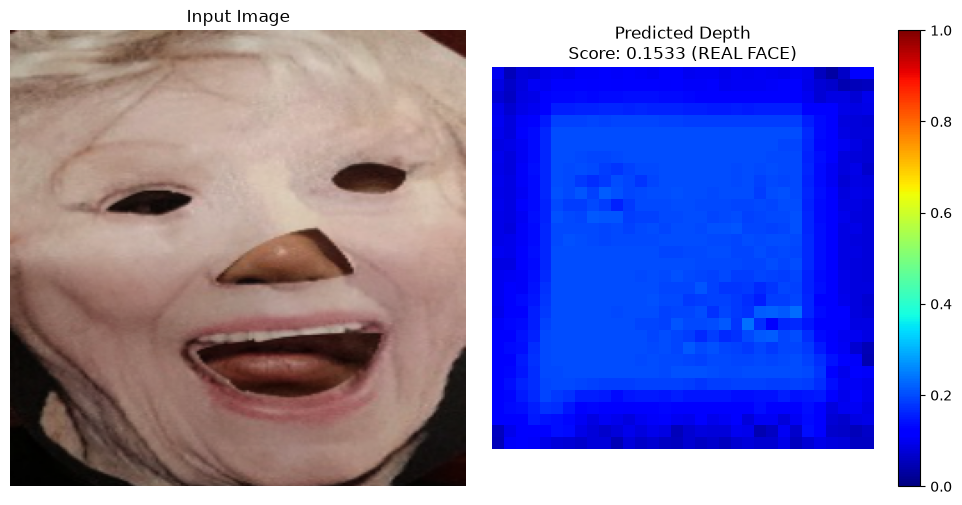

In [20]:
test_row = ds[171] 
test_img_pil = test_row.get('cropped_image') or test_row.get('image')
test_img_array = np.array(test_img_pil.convert('RGB'))
    
    # Draw the Depth Map
test_and_visualize(model, test_img_array)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load image directly from path ─────────────────────────────────────────
IMAGE_PATH = r"C:\Users\anubh\OneDrive\Pictures\Camera Roll\WIN_20260617_00_42_02_Pro.jpg"

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ── 2. Face detection ─────────────────────────────────────────────────────────
# cv2.data.haarcascades is broken in this environment's opencv-contrib-python
# install (no bundled cascade data on disk), so reuse the cascade already
# downloaded to _HAAR_PATH by the "Geometry-based depth targets" cell above.
face_cascade = cv2.CascadeClassifier(_HAAR_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

if len(faces) == 0:
    print("No face detected — using the full image as-is.")
    cropped = img_rgb
else:
    x, y, w, h = faces[0]
    # 20% padding around bounding box (matches CelebA-Spoof style)
    pad = int(max(w, h) * 0.20)
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(img_rgb.shape[1], x + w + pad)
    y2 = min(img_rgb.shape[0], y + h + pad)
    cropped = img_rgb[y1:y2, x1:x2]
    print(f"Face detected at ({x},{y}) size {w}x{h}  ->  crop {cropped.shape[:2]}")

# ── 3. Resize to 256x256 (model input format) ─────────────────────────────────
face_256 = cv2.resize(cropped, (256, 256))

plt.figure(figsize=(4, 4))
plt.imshow(face_256)
plt.title("Cropped & Resized Input (256x256)")
plt.axis('off')
plt.show()

# ── 4. Run CDCN inference ─────────────────────────────────────────────────────
test_and_visualize(model, face_256)


## Validation metrics: loss, liveness classification, and PAD metrics on CelebA-Spoof

`nguyenkhoa/celeba-spoof-for-face-antispoofing-test` only ships a single `test` split, and the training cell above splits it 80/20 (`ds_train_pool` / `ds_val`) so evaluation never sees images used in training.

Reported metrics:
- **Loss** — the combined depth (MSE + contrastive depth) and auxiliary classification (BCE) loss used in training, via `model.evaluate`.
- **Liveness score** — the auxiliary classification head's sigmoid output (`preds['cls']`), used directly as the score. This replaced the earlier "mean of the predicted depth map" proxy, which had no direct classification gradient behind it.
- **Threshold** — calibrated per evaluation run by sweeping the ROC curve and picking the point that minimizes ACER, rather than a hardcoded constant.
- **APCER / BPCER / ACER** — the standard ISO/IEC 30107-3 presentation-attack-detection metrics: APCER is the fraction of spoof samples wrongly accepted as live (security risk), BPCER is the fraction of live samples wrongly rejected as spoof (usability cost), and ACER is their average.

In [15]:
# scikit-learn is already installed in this environment; the earlier
# `pip install sklearn` failed because that PyPI name is a deprecated
# meta-package. Use `scikit-learn` if you ever need to (re)install it:
# pip install scikit-learn


In [ ]:
# ── Quick validation on a shuffled 2,000-sample subset ────────────────────────
# ds_val.select(range(2000)) grabbed a spoof-only slice last time (CelebA-Spoof
# is heavily imbalanced and the rows weren't shuffled at this point). Shuffle
# first so the subset actually contains both classes.
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, roc_curve,
)

# get_label is defined once in the "Geometry-based depth targets" cell above
# and reused here and by the generator, instead of each cell keeping its own
# copy.

ds_val_live = ds_val.filter(lambda v: int(v) == 0, input_columns=['labels'])   # 0 = live
ds_val_spoof = ds_val.filter(lambda v: int(v) == 1, input_columns=['labels'])  # 1 = spoof

n_per_class = min(1000, len(ds_val_live), len(ds_val_spoof))
ds_val_balanced = datasets.concatenate_datasets([
    ds_val_live.shuffle(seed=42).select(range(n_per_class)),
    ds_val_spoof.shuffle(seed=42).select(range(n_per_class)),
]).shuffle(seed=42)

print(f"Live available: {len(ds_val_live)}, Spoof available: {len(ds_val_spoof)}")
print(f"Balanced subset: {len(ds_val_balanced)} samples "
      f"({n_per_class} live + {n_per_class} spoof)")

def evaluate_cdcn_fresh(model, hf_dataset, batch_size=8):
    """Scores `model` on `hf_dataset` using the auxiliary classification
    head's sigmoid output as the liveness score, with the decision threshold
    calibrated (per this evaluation run) to minimize ACER rather than fixed
    at an arbitrary constant. batch_size=8 (not 16): a batch_size=16 forward
    pass here OOM'd after a long training run, since the GPU's memory pool
    was fragmented by then -- 8 fits with headroom to spare for inference."""
    gen = CelebASpoofGenerator(hf_dataset, batch_size=batch_size, augment=False)

    print("Computing mean loss (model.evaluate)...")
    loss_results = model.evaluate(gen, verbose=0, return_dict=True)
    mean_loss = loss_results.get('loss', float('nan'))

    y_true, y_score = [], []
    for i in range(len(gen)):
        batch_x, batch_y = gen[i]
        preds = model.predict(batch_x, verbose=0)
        batch_idx = gen.indices[i * batch_size:(i + 1) * batch_size]
        for j, idx in enumerate(batch_idx):
            y_true.append(get_label(hf_dataset[int(idx)]))
            y_score.append(float(preds['cls'][j, 0]))
        if (i + 1) % 25 == 0 or (i + 1) == len(gen):
            print(f"  batch {i+1}/{len(gen)}")

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    # ROC curve gives fpr = P(predict live | spoof) = APCER and
    # tpr = P(predict live | live) = 1 - BPCER at every achievable threshold;
    # pick the threshold that minimizes their average (ACER).
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    acer_curve = (fpr + (1 - tpr)) / 2
    best_idx = np.argmin(acer_curve)
    best_threshold = thresholds[best_idx]

    y_pred = (y_score >= best_threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = float('nan')
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    apcer = float(np.mean(y_pred[y_true == 0] == 1)) if np.any(y_true == 0) else float('nan')
    bpcer = float(np.mean(y_pred[y_true == 1] == 0)) if np.any(y_true == 1) else float('nan')
    acer = (apcer + bpcer) / 2

    print(f"\nSamples evaluated      : {len(y_true)}")
    print(f"Mean loss (depth+cls)  : {mean_loss:.4f}")
    print(f"Calibrated threshold   : {best_threshold:.4f}  (chosen to minimize ACER on this set)")
    print(f"Accuracy               : {acc:.4f}")
    print(f"Precision              : {precision:.4f}")
    print(f"Recall                 : {recall:.4f}")
    print(f"F1                     : {f1:.4f}")
    print(f"ROC-AUC                : {auc:.4f}")
    print(f"APCER (spoof -> live)  : {apcer:.4f}")
    print(f"BPCER (live -> spoof)  : {bpcer:.4f}")
    print(f"ACER                   : {acer:.4f}")
    print(f"Confusion matrix (rows=true, cols=pred) [0=spoof, 1=live]:\n{cm}")

evaluate_cdcn_fresh(model, ds_val_balanced, batch_size=8)


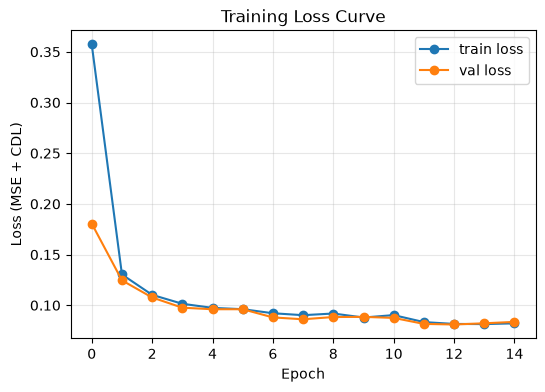

Train loss per epoch: [0.35722213983535767, 0.13038073480129242, 0.11027268320322037, 0.10146920382976532, 0.09742666780948639, 0.09614343196153641, 0.09213053435087204, 0.09022018313407898, 0.09187574684619904, 0.08791790902614594, 0.09030363708734512, 0.08341047167778015, 0.08159492909908295, 0.08144278824329376, 0.08217335492372513]
Val loss per epoch:   [0.1805686354637146, 0.12457454949617386, 0.10768873244524002, 0.09761276841163635, 0.09609168022871017, 0.09609635919332504, 0.08802077919244766, 0.08619339019060135, 0.08841238170862198, 0.08855688571929932, 0.08754801005125046, 0.08162416517734528, 0.0810391753911972, 0.0822305977344513, 0.08360258489847183]


In [17]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], marker='o', label='train loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], marker='o', label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE + CDL)')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Train loss per epoch:", history.history['loss'])
if 'val_loss' in history.history:
    print("Val loss per epoch:  ", history.history['val_loss'])

## Edge deployment: post-training quantization (TFLite)

Target: a generic ARM SBC (Raspberry Pi-class) or Android phone via the standard
TensorFlow Lite runtime. This uses **post-training quantization (PTQ)** on the
already-trained checkpoint -- no retraining. Quantization-aware training (QAT)
was considered but skipped: `CDCNpp` is a subclassed Keras model with a custom
`CDC` layer, and TF's QAT tooling (`tfmot`) is built for Functional/Sequential
models with registered layer types, so QAT here would require rewriting the
model and authoring a custom quantization config for `CDC`. PTQ operates on the
frozen inference graph regardless of how the original model was structured, so
it's the direct path.

Four variants are produced and compared on the same held-out validation set
used throughout this notebook:
- **FP32** -- plain TFLite conversion, no quantization (fair CPU-latency baseline
  for the other three, since comparing a GPU-run Keras model against a
  CPU-run TFLite model wouldn't be apples-to-apples).
- **Dynamic-range** -- int8 weights, float activations. No calibration data needed.
- **Float16** -- halves size, closest to FP32 accuracy, mainly benefits
  GPU/float16-capable delegates rather than generic CPU.
- **Full-integer (int8)** -- int8 weights *and* activations, calibrated on 200
  images sampled from the **training pool** (never the held-out validation set
  used for accuracy reporting below).

One export detail worth noting: exporting via a plain `tf.saved_model.save()`
call on this subclassed model left a BatchNorm-related variable as an
unresolved `READ_VARIABLE` op, which caused full-int8 conversion to fail
outright. Keras 3's `Model.export()` -- built specifically for producing a
fully-frozen, inference-only SavedModel -- resolved this; that's what's used
below.

In [ ]:
import time
import json
import csv

QUANT_DIR = os.path.expanduser('~/cdcn_quantized')
os.makedirs(QUANT_DIR, exist_ok=True)

# Rebuild the model fresh from the checkpoint rather than relying on the
# in-memory `model` from the training cell -- keeps this section runnable on
# its own (e.g. after a kernel restart) without retraining.
quant_model = CDCNpp()
_ = quant_model(tf.zeros((1, 256, 256, 3)), training=False)
quant_model.load_weights('cdcnpp_best.weights.h5')
H5_SIZE_BYTES = os.path.getsize('cdcnpp_best.weights.h5')

SAVEDMODEL_DIR = os.path.join(QUANT_DIR, 'saved_model')
print(f"Exporting frozen SavedModel to {SAVEDMODEL_DIR} ...")
quant_model.export(SAVEDMODEL_DIR, input_signature=[tf.TensorSpec([1, 256, 256, 3], tf.float32, name='input_image')])
print("SavedModel export OK.")

# ── Calibration set for full-int8 PTQ, drawn only from the training pool ────
N_CALIB = 200
calib_subset = ds_train_pool.shuffle(seed=123).select(range(N_CALIB + 50))


def load_and_preprocess(row):
    """Returns None if this row has no usable image (a handful of CelebA-Spoof
    rows lack both 'cropped_image' and 'image') -- mirrors the same guard
    CelebASpoofGenerator.__getitem__ applies."""
    img_pil = row.get('cropped_image') or row.get('image')
    if img_pil is None:
        return None
    img = np.array(img_pil.convert('RGB'))
    img = cv2.resize(img, (256, 256))
    return (img / 255.0).astype(np.float32)


def representative_dataset():
    count, i = 0, 0
    while count < N_CALIB and i < len(calib_subset):
        img = load_and_preprocess(calib_subset[i])
        i += 1
        if img is None:
            continue
        count += 1
        yield [np.expand_dims(img, axis=0)]


# ── Convert four variants through the same SavedModel ───────────────────────
variants = {}

print("Converting: fp32 (no quantization, TFLite baseline)...")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(SAVEDMODEL_DIR)
    variants['fp32'] = converter.convert()
    print("  OK")
except Exception as e:
    print(f"  FAILED: {e}")

print("Converting: dynamic-range quantization...")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(SAVEDMODEL_DIR)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    variants['dynamic_range'] = converter.convert()
    print("  OK")
except Exception as e:
    print(f"  FAILED: {e}")

print("Converting: float16 quantization...")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(SAVEDMODEL_DIR)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    variants['float16'] = converter.convert()
    print("  OK")
except Exception as e:
    print(f"  FAILED: {e}")

print("Converting: full-integer (int8) quantization...")
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(SAVEDMODEL_DIR)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    variants['full_int8'] = converter.convert()
    print("  OK")
except Exception as e:
    print(f"  FAILED: {e}")

print(f"\nConverted variants: {list(variants.keys())}")

sizes = {}
for name, content in variants.items():
    path = os.path.join(QUANT_DIR, f'cdcnpp_{name}.tflite')
    with open(path, 'wb') as f:
        f.write(content)
    sizes[name] = os.path.getsize(path)
    print(f"  {name}: {sizes[name] / 1024:.1f} KB -> {path}")

print(f"\nOriginal .h5 checkpoint size: {H5_SIZE_BYTES / 1024:.1f} KB")

In [ ]:
def find_output_index(output_details):
    """cls output has shape (1,1); depth output has shape (1,32,32,1) --
    distinguish by element count rather than name/order."""
    cls_idx = depth_idx = None
    for i, od in enumerate(output_details):
        n = int(np.prod(od['shape']))
        if n == 1:
            cls_idx = i
        else:
            depth_idx = i
    return cls_idx, depth_idx


def evaluate_tflite(tflite_bytes, hf_dataset, num_threads=1):
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes, num_threads=num_threads)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    cls_idx, depth_idx = find_output_index(output_details)
    in_dtype = input_details[0]['dtype']
    in_scale, in_zero = input_details[0].get('quantization', (0.0, 0))
    out_scale, out_zero = output_details[cls_idx].get('quantization', (0.0, 0))

    y_true, y_score = [], []
    for i in range(len(hf_dataset)):
        row = hf_dataset[int(i)]
        img = load_and_preprocess(row)
        if img is None:
            continue
        img_batch = np.expand_dims(img, axis=0)
        if in_dtype in (np.int8, np.uint8):
            img_batch = (img_batch / in_scale + in_zero).astype(in_dtype)
        interpreter.set_tensor(input_details[0]['index'], img_batch)
        interpreter.invoke()
        raw = interpreter.get_tensor(output_details[cls_idx]['index'])
        score = float(raw.reshape(-1)[0])
        if out_scale:
            score = (score - out_zero) * out_scale
        y_true.append(get_label(row))
        y_score.append(score)
        if (i + 1) % 250 == 0:
            print(f"    {i+1}/{len(hf_dataset)}")
    return np.array(y_true), np.array(y_score)


def compute_metrics(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    acer_curve = (fpr + (1 - tpr)) / 2
    best_idx = int(np.argmin(acer_curve))
    best_threshold = thresholds[best_idx]
    y_pred = (y_score >= best_threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = float('nan')
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    apcer = float(np.mean(y_pred[y_true == 0] == 1)) if np.any(y_true == 0) else float('nan')
    bpcer = float(np.mean(y_pred[y_true == 1] == 0)) if np.any(y_true == 1) else float('nan')
    acer = (apcer + bpcer) / 2
    return dict(accuracy=acc, precision=precision, recall=recall, f1=f1, roc_auc=auc,
                apcer=apcer, bpcer=bpcer, acer=acer, threshold=float(best_threshold),
                confusion_matrix=cm.tolist())


def measure_latency(tflite_bytes, hf_dataset, n=100, num_threads=1):
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes, num_threads=num_threads)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    in_dtype = input_details[0]['dtype']
    in_scale, in_zero = input_details[0].get('quantization', (0.0, 0))

    imgs = []
    i = 0
    while len(imgs) < n and i < len(hf_dataset):
        img = load_and_preprocess(hf_dataset[int(i)])
        i += 1
        if img is None:
            continue
        img_batch = np.expand_dims(img, axis=0)
        if in_dtype in (np.int8, np.uint8):
            img_batch = (img_batch / in_scale + in_zero).astype(in_dtype)
        imgs.append(img_batch)

    for img_batch in imgs[:5]:  # warmup
        interpreter.set_tensor(input_details[0]['index'], img_batch)
        interpreter.invoke()

    times = []
    for img_batch in imgs:
        t0 = time.perf_counter()
        interpreter.set_tensor(input_details[0]['index'], img_batch)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details[0]['index'])
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))


# ── Evaluate every variant on the SAME held-out ds_val_balanced used earlier
#    in this notebook (seed=42, 1000 live + 1000 spoof) ─────────────────────
quant_results = {}
for name, content in variants.items():
    print(f"\n=== Evaluating variant: {name} ===")
    y_true, y_score = evaluate_tflite(content, ds_val_balanced)
    metrics = compute_metrics(y_true, y_score)
    mean_ms, std_ms = measure_latency(content, ds_val_balanced, n=100)
    metrics['size_kb'] = sizes[name] / 1024
    metrics['latency_ms_mean'] = mean_ms
    metrics['latency_ms_std'] = std_ms
    quant_results[name] = metrics
    print(f"  ACER={metrics['acer']*100:.3f}%  APCER={metrics['apcer']*100:.3f}%  "
          f"BPCER={metrics['bpcer']*100:.3f}%  AUC={metrics['roc_auc']:.4f}  "
          f"size={metrics['size_kb']:.1f}KB  latency={mean_ms:.2f}+/-{std_ms:.2f}ms")

with open(os.path.join(QUANT_DIR, 'quantization_results.json'), 'w') as f:
    json.dump(quant_results, f, indent=2)

In [ ]:
# ── Comparison table + figure for the paper ──────────────────────────────────
ORDER = ['fp32', 'dynamic_range', 'float16', 'full_int8']
LABELS = ['FP32\n(TFLite)', 'Dynamic-range\nINT8', 'Float16', 'Full INT8']
COLORS = ['#0072B2', '#009E73', '#E69F00', '#D55E00']  # Okabe-Ito, fixed categorical order

sizes_mb = [quant_results[k]['size_kb'] / 1024 for k in ORDER]
latency_ms = [quant_results[k]['latency_ms_mean'] for k in ORDER]
latency_std = [quant_results[k]['latency_ms_std'] for k in ORDER]
acer_pct = [quant_results[k]['acer'] * 100 for k in ORDER]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

bars = axes[0].bar(LABELS, sizes_mb, color=COLORS)
axes[0].set_ylabel('Model size (MB)')
axes[0].set_title('Size')
for b, v in zip(bars, sizes_mb):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

bars = axes[1].bar(LABELS, latency_ms, yerr=latency_std, color=COLORS, capsize=3)
axes[1].set_ylabel('Mean latency (ms/image, host CPU, 1 thread)')
axes[1].set_title('Latency')
for b, v in zip(bars, latency_ms):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

bars = axes[2].bar(LABELS, acer_pct, color=COLORS)
axes[2].set_ylabel('ACER (%)')
axes[2].set_title('Accuracy (lower is better)')
axes[2].set_yscale('symlog', linthresh=0.1)
for b, v in zip(bars, acer_pct):
    axes[2].text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', labelsize=9)
    for label in ax.get_xticklabels():
        label.set_rotation(15)
        label.set_ha('right')

fig.suptitle('CDCN++ post-training quantization: size vs. latency vs. accuracy', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(QUANT_DIR, 'fig_quantization_comparison.png'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(QUANT_DIR, 'fig_quantization_comparison.pdf'), bbox_inches='tight')
plt.show()

header = ['Variant', 'Size (MB)', 'ACER (%)', 'APCER (%)', 'BPCER (%)', 'ROC-AUC', 'Latency (ms, host CPU)']
rows = []
for k, label in zip(ORDER, LABELS):
    r = quant_results[k]
    rows.append([
        label.replace('\n', ' '),
        f"{r['size_kb']/1024:.2f}",
        f"{r['acer']*100:.3f}",
        f"{r['apcer']*100:.3f}",
        f"{r['bpcer']*100:.3f}",
        f"{r['roc_auc']:.4f}",
        f"{r['latency_ms_mean']:.1f} +/- {r['latency_ms_std']:.1f}",
    ])

with open(os.path.join(QUANT_DIR, 'quantization_comparison.csv'), 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(header)
    w.writerows(rows)
with open(os.path.join(QUANT_DIR, 'quantization_comparison.md'), 'w') as f:
    f.write('| ' + ' | '.join(header) + ' |\n')
    f.write('|' + '---|' * len(header) + '\n')
    for row in rows:
        f.write('| ' + ' | '.join(row) + ' |\n')

print('| ' + ' | '.join(header) + ' |')
print('|' + '---|' * len(header))
for row in rows:
    print('| ' + ' | '.join(row) + ' |')

print(f"\nNote: latency figures are measured on this host machine's CPU (single-threaded), "
      f"not on actual Raspberry Pi/Android hardware -- treat as a relative comparison "
      f"between variants, not an absolute edge-device number.")